In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#LOADING THE DATA
import pandas as pd
import zipfile
import io
import os

# Check environment to decide upload method
try:
    from google.colab import files
    IS_COLAB = True
except ImportError:
    IS_COLAB = False
    from tkinter import Tk
    from tkinter.filedialog import askopenfilename

print("📂 Please upload your .zip file from Kaggle...")

uploaded_file_name = None
file_content = None

if IS_COLAB:
    # --- Google Colab Method ---
    uploaded = files.upload()
    uploaded_file_name = list(uploaded.keys())[0]
    file_content = uploaded[uploaded_file_name]
else:
    # --- Local Jupyter Method ---
    Tk().withdraw()
    uploaded_file_name = askopenfilename(
        title="Select the .zip file",
        filetypes=[("Zip Files", "*.zip")]
    )
    if uploaded_file_name:
        with open(uploaded_file_name, 'rb') as f:
            file_content = f.read()

if file_content:
    print(f"✅ File '{uploaded_file_name}' uploaded successfully!")

    try:
        # Step 1: Open the Zip File
        with zipfile.ZipFile(io.BytesIO(file_content) if IS_COLAB else io.BytesIO(file_content), 'r') as zip_ref:
            # List all files inside the zip
            file_list = zip_ref.namelist()
            print(f"\n📦 Files found inside the zip: {file_list}")

            # Step 2: Find the correct data file (looking for .xlsx or .csv)
            target_file = None
            for name in file_list:
                if name.endswith('.xlsx') or name.endswith('.csv'):
                    # Avoid hidden system files like __MACOSX
                    if not name.startswith('__'):
                        target_file = name
                        break

            if target_file:
                print(f"🎯 Found data file: {target_file}")

                # Step 3: Read the file directly from the zip
                with zip_ref.open(target_file) as f:
                    if target_file.endswith('.csv'):
                        df_raw = pd.read_csv(f, encoding='latin-1') # latin-1 often handles special chars better
                    else:
                        # For Excel, we might need to save it temporarily or use BytesIO carefully
                        # Pandas read_excel sometimes struggles with direct zip streams depending on version
                        # Safest bet: Extract to memory bytes
                        content_bytes = f.read()
                        df_raw = pd.read_excel(io.BytesIO(content_bytes))

                print("\n✅ Data Loaded Successfully!")
                print(f"Shape: {df_raw.shape}")
                print("\n--- First 5 Rows ---")
                print(df_raw.head())
                print("\n--- Column Names ---")
                print(df_raw.columns.tolist())

            else:
                print("❌ No .xlsx or .csv file found inside the zip archive.")
                df_raw = pd.DataFrame()

    except Exception as e:
        print(f"❌ Error processing zip file: {e}")
        print("Tip: Ensure the zip file actually contains an Excel or CSV file.")
        df_raw = pd.DataFrame()
else:
    print("❌ No file uploaded.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots look good
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("🚀 Starting Data Preprocessing Pipeline...")

# ==========================================
# STEP 1: INITIAL CLEANING (As per Chapter 3)
# ==========================================

# Store original count for comparison
original_count = len(df_raw)
print(f"1. Original Record Count: {original_count:,}")

# 1. Drop rows with missing CustomerID (Listwise Deletion)
# We also drop missing Description as per our methodology
missing_customerid = df_raw['Customer ID'].isnull().sum()
missing_description = df_raw['Description'].isnull().sum()

df_clean = df_raw.dropna(subset=['Customer ID', 'Description'])
print(f"   - Removed {missing_customerid:,} rows with missing Customer ID.")
print(f"   - Removed {missing_description:,} rows with missing Description.")
print(f"   Count after dropping nulls: {len(df_clean):,}")

# 2. Remove Cancellations (Negative Quantity or Price)
# These represent returns/cancellations and skew CX analysis
neg_quantity = (df_clean['Quantity'] < 0).sum()
neg_price = (df_clean['Price'] < 0).sum()

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"   - Removed {neg_quantity:,} rows with negative Quantity.")
print(f"   - Removed {neg_price:,} rows with negative Price.")
print(f"   Count after removing negatives: {len(df_clean):,}")

# 3. Remove Duplicates
# Based on InvoiceNo and StockCode to avoid double counting line items
duplicates = df_clean.duplicated(subset=['Invoice', 'StockCode', 'Quantity']).sum()
df_clean = df_clean.drop_duplicates(subset=['Invoice', 'StockCode', 'Quantity'])
print(f"   - Removed {duplicates:,} duplicate rows.")
print(f"   Final Cleaned Count: {len(df_clean):,}")

# Calculate Retention Rate
retention_rate = (len(df_clean) / original_count) * 100
print(f"\n📊 Data Retention Rate: {retention_rate:.2f}%")

# ==========================================
# STEP 2: FEATURE ENGINEERING
# ==========================================

# 1. Create TotalAmount column
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

# 2. Convert InvoiceDate to datetime
# Note: If your date format is unusual, pandas usually guesses correctly,
# but we can enforce it if needed.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 3. Extract Time Features for later analysis
df_clean['InvoiceYear'] = df_clean['InvoiceDate'].dt.year
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.month
df_clean['InvoiceDay'] = df_clean['InvoiceDate'].dt.day
df_clean['InvoiceHour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

# 4. Define Reference Date for Recency Calculation
# This is crucial for RFM analysis in Phase 2
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"\n✅ Feature Engineering Complete.")
print(f"   Reference Date for Recency: {reference_date}")

# ==========================================
# STEP 3: SAVE CLEANED DATA
# ==========================================
output_filename = 'cleaned_retail_data.csv'
df_clean.to_csv(output_filename, index=False)
print(f"\n💾 Cleaned dataset saved as '{output_filename}'")
print("   (You will use this file for all subsequent phases)")

# ==========================================
# STEP 4: GENERATE CHAPTER 4 STATS TABLE
# ==========================================
stats_summary = {
    'Metric': [
        'Original Records',
        'Missing CustomerID Removed',
        'Missing Description Removed',
        'Negative Transactions Removed',
        'Duplicates Removed',
        'Final Cleaned Records',
        'Data Retention %',
        'Unique Customers',
        'Unique Products (StockCodes)',
        'Date Range'
    ],
    'Value': [
        f"{original_count:,}",
        f"{missing_customerid:,}",
        f"{missing_description:,}",
        f"{neg_quantity + neg_price:,}", # Combined for simplicity in table
        f"{duplicates:,}",
        f"{len(df_clean):,}",
        f"{retention_rate:.2f}%",
        f"{df_clean['Customer ID'].nunique():,}",
        f"{df_clean['StockCode'].nunique():,}",
        f"{df_clean['InvoiceDate'].min().strftime('%Y-%m-%d')} to {df_clean['InvoiceDate'].max().strftime('%Y-%m-%d')}"
    ]
}

stats_df = pd.DataFrame(stats_summary)

print("\n" + "="*50)
print("📋 TABLE 4.1: DATA CLEANING STATISTICS (Copy for Dissertation)")
print("="*50)
print(stats_df.to_string(index=False))
print("="*50)

# Optional: Display first few rows to verify
print("\n--- Preview of Cleaned Data ---")
print(df_clean[['Invoice', 'Customer ID', 'Description', 'Quantity', 'Price', 'TotalAmount', 'InvoiceDate']].head())




📂 Please upload your .zip file from Kaggle...


Saving archive.zip to archive (3).zip
✅ File 'archive (3).zip' uploaded successfully!

📦 Files found inside the zip: ['online_retail_II.csv']
🎯 Found data file: online_retail_II.csv

✅ Data Loaded Successfully!
Shape: (1067371, 8)

--- First 5 Rows ---
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#LOADING THE DATA
import pandas as pd
import zipfile
import io
import os

# Check environment to decide upload method
try:
    from google.colab import files
    IS_COLAB = True
except ImportError:
    IS_COLAB = False
    from tkinter import Tk
    from tkinter.filedialog import askopenfilename

print("📂 Please upload your .zip file from Kaggle...")

uploaded_file_name = None
file_content = None

if IS_COLAB:
    # --- Google Colab Method ---
    uploaded = files.upload()
    uploaded_file_name = list(uploaded.keys())[0]
    file_content = uploaded[uploaded_file_name]
else:
    # --- Local Jupyter Method ---
    Tk().withdraw()
    uploaded_file_name = askopenfilename(
        title="Select the .zip file",
        filetypes=[("Zip Files", "*.zip")]
    )
    if uploaded_file_name:
        with open(uploaded_file_name, 'rb') as f:
            file_content = f.read()

if file_content:
    print(f"✅ File '{uploaded_file_name}' uploaded successfully!")

    try:
        # Step 1: Open the Zip File
        with zipfile.ZipFile(io.BytesIO(file_content) if IS_COLAB else io.BytesIO(file_content), 'r') as zip_ref:
            # List all files inside the zip
            file_list = zip_ref.namelist()
            print(f"\n📦 Files found inside the zip: {file_list}")

            # Step 2: Find the correct data file (looking for .xlsx or .csv)
            target_file = None
            for name in file_list:
                if name.endswith('.xlsx') or name.endswith('.csv'):
                    # Avoid hidden system files like __MACOSX
                    if not name.startswith('__'):
                        target_file = name
                        break

            if target_file:
                print(f"🎯 Found data file: {target_file}")

                # Step 3: Read the file directly from the zip
                with zip_ref.open(target_file) as f:
                    if target_file.endswith('.csv'):
                        df_raw = pd.read_csv(f, encoding='latin-1') # latin-1 often handles special chars better
                    else:
                        # For Excel, we might need to save it temporarily or use BytesIO carefully
                        # Pandas read_excel sometimes struggles with direct zip streams depending on version
                        # Safest bet: Extract to memory bytes
                        content_bytes = f.read()
                        df_raw = pd.read_excel(io.BytesIO(content_bytes))

                print("\n✅ Data Loaded Successfully!")
                print(f"Shape: {df_raw.shape}")
                print("\n--- First 5 Rows ---")
                print(df_raw.head())
                print("\n--- Column Names ---")
                print(df_raw.columns.tolist())

            else:
                print("❌ No .xlsx or .csv file found inside the zip archive.")
                df_raw = pd.DataFrame()

    except Exception as e:
        print(f"❌ Error processing zip file: {e}")
        print("Tip: Ensure the zip file actually contains an Excel or CSV file.")
        df_raw = pd.DataFrame()
else:
    print("❌ No file uploaded.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots look good
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("🚀 Starting Data Preprocessing Pipeline...")

# ==========================================
# STEP 1: INITIAL CLEANING (As per Chapter 3)
# ==========================================

# Store original count for comparison
original_count = len(df_raw)
print(f"1. Original Record Count: {original_count:,}")

# 1. Drop rows with missing CustomerID (Listwise Deletion)
# We also drop missing Description as per our methodology
missing_customerid = df_raw['Customer ID'].isnull().sum()
missing_description = df_raw['Description'].isnull().sum()

df_clean = df_raw.dropna(subset=['Customer ID', 'Description'])
print(f"   - Removed {missing_customerid:,} rows with missing Customer ID.")
print(f"   - Removed {missing_description:,} rows with missing Description.")
print(f"   Count after dropping nulls: {len(df_clean):,}")

# 2. Remove Cancellations (Negative Quantity or Price)
# These represent returns/cancellations and skew CX analysis
neg_quantity = (df_clean['Quantity'] < 0).sum()
neg_price = (df_clean['Price'] < 0).sum()

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"   - Removed {neg_quantity:,} rows with negative Quantity.")
print(f"   - Removed {neg_price:,} rows with negative Price.")
print(f"   Count after removing negatives: {len(df_clean):,}")

# 3. Remove Duplicates
# Based on InvoiceNo and StockCode to avoid double counting line items
duplicates = df_clean.duplicated(subset=['Invoice', 'StockCode', 'Quantity']).sum()
df_clean = df_clean.drop_duplicates(subset=['Invoice', 'StockCode', 'Quantity'])
print(f"   - Removed {duplicates:,} duplicate rows.")
print(f"   Final Cleaned Count: {len(df_clean):,}")

# Calculate Retention Rate
retention_rate = (len(df_clean) / original_count) * 100
print(f"\n📊 Data Retention Rate: {retention_rate:.2f}%")

# ==========================================
# STEP 2: FEATURE ENGINEERING
# ==========================================

# 1. Create TotalAmount column
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

# 2. Convert InvoiceDate to datetime
# Note: If your date format is unusual, pandas usually guesses correctly,
# but we can enforce it if needed.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 3. Extract Time Features for later analysis
df_clean['InvoiceYear'] = df_clean['InvoiceDate'].dt.year
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.month
df_clean['InvoiceDay'] = df_clean['InvoiceDate'].dt.day
df_clean['InvoiceHour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

# 4. Define Reference Date for Recency Calculation
# This is crucial for RFM analysis in Phase 2
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"\n✅ Feature Engineering Complete.")
print(f"   Reference Date for Recency: {reference_date}")

# ==========================================
# STEP 3: SAVE CLEANED DATA
# ==========================================
output_filename = 'cleaned_retail_data.csv'
df_clean.to_csv(output_filename, index=False)
print(f"\n💾 Cleaned dataset saved as '{output_filename}'")
print("   (You will use this file for all subsequent phases)")

# ==========================================
# STEP 4: GENERATE CHAPTER 4 STATS TABLE
# ==========================================
stats_summary = {
    'Metric': [
        'Original Records',
        'Missing CustomerID Removed',
        'Missing Description Removed',
        'Negative Transactions Removed',
        'Duplicates Removed',
        'Final Cleaned Records',
        'Data Retention %',
        'Unique Customers',
        'Unique Products (StockCodes)',
        'Date Range'
    ],
    'Value': [
        f"{original_count:,}",
        f"{missing_customerid:,}",
        f"{missing_description:,}",
        f"{neg_quantity + neg_price:,}", # Combined for simplicity in table
        f"{duplicates:,}",
        f"{len(df_clean):,}",
        f"{retention_rate:.2f}%",
        f"{df_clean['Customer ID'].nunique():,}",
        f"{df_clean['StockCode'].nunique():,}",
        f"{df_clean['InvoiceDate'].min().strftime('%Y-%m-%d')} to {df_clean['InvoiceDate'].max().strftime('%Y-%m-%d')}"
    ]
}

stats_df = pd.DataFrame(stats_summary)

print("\n" + "="*50)
print("📋 TABLE 4.1: DATA CLEANING STATISTICS (Copy for Dissertation)")
print("="*50)
print(stats_df.to_string(index=False))
print("="*50)

# Optional: Display first few rows to verify
print("\n--- Preview of Cleaned Data ---")
print(df_clean[['Invoice', 'Customer ID', 'Description', 'Quantity', 'Price', 'TotalAmount', 'InvoiceDate']].head())




📂 Please upload your .zip file from Kaggle...


Saving archive.zip to archive (3).zip
✅ File 'archive (3).zip' uploaded successfully!

📦 Files found inside the zip: ['online_retail_II.csv']
🎯 Found data file: online_retail_II.csv

✅ Data Loaded Successfully!
Shape: (1067371, 8)

--- First 5 Rows ---
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:0

📂 Please upload your .zip file from Kaggle or a cleaned_retail_data.csv file...


Saving cleaned_retail_data.csv to cleaned_retail_data (13).csv
✅ File 'cleaned_retail_data (13).csv' uploaded successfully!

✅ Data Loaded Successfully!
Shape: (779390, 14)

--- First 5 Rows ---
   Invoice StockCode                          Description  Quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   
3   489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4   489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  TotalAmount  \
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom         83.4   
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom         81.0   
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom         81.0   
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom        100.8   
4  

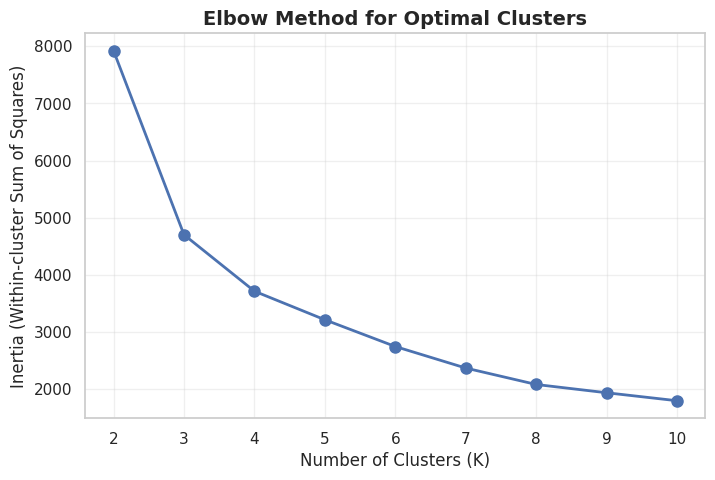


💡 Selected K=4 for final model.

📋 TABLE 4.2: CLUSTER PROFILES (Copy this for Dissertation)
         Recency  Frequency  Monetary  Count
Cluster                                     
2          60.77       9.79   2851.83    543
3         122.86       5.20   1636.41   1108
0          96.88       2.10    520.87   1719
1         488.50       1.66    441.22   1631
🚀 Generating 3D Visualization (Step 7)...


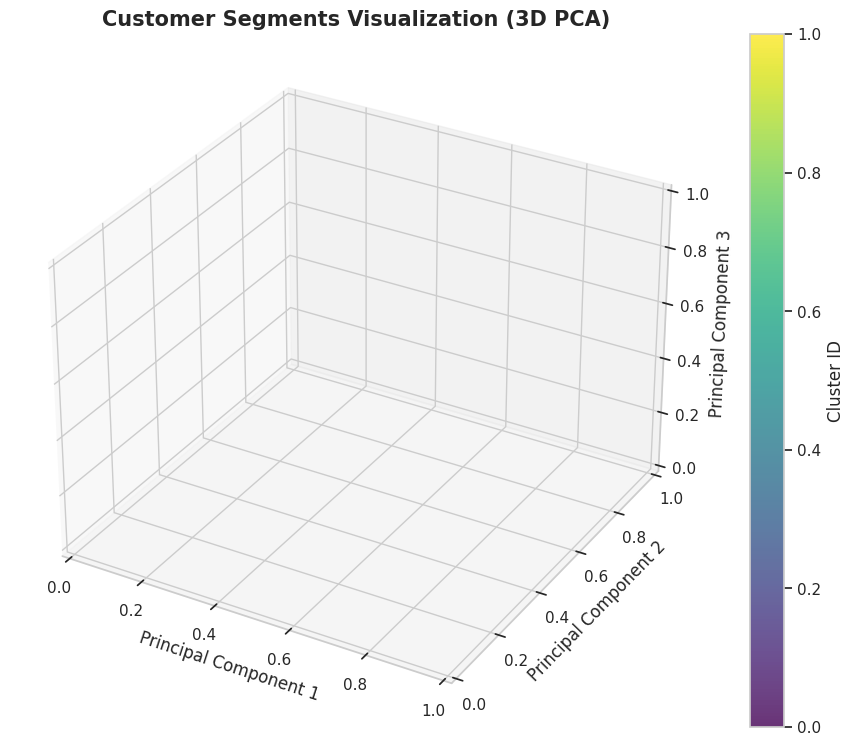

✅ 3D Plot generated successfully!
💡 Tip: Right-click the plot to save it for your dissertation (Figure 4.2).


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#LOADING THE DATA
import pandas as pd
import zipfile
import io
import os

# Check environment to decide upload method
try:
    from google.colab import files
    IS_COLAB = True
except ImportError:
    IS_COLAB = False
    from tkinter import Tk
    from tkinter.filedialog import askopenfilename

print("📂 Please upload your .zip file from Kaggle or a cleaned_retail_data.csv file...")

uploaded_file_name = None
file_content = None

if IS_COLAB:
    # --- Google Colab Method ---
    uploaded = files.upload()
    if uploaded:
        uploaded_file_name = list(uploaded.keys())[0]
        file_content = uploaded[uploaded_file_name]
    else:
        print("❌ No file uploaded.")
else:
    # --- Local Jupyter Method ---
    Tk().withdraw()
    uploaded_file_name = askopenfilename(
        title="Select the .zip or .csv file",
        filetypes=[("Zip Files", "*.zip"), ("CSV Files", "*.csv")]
    )
    if uploaded_file_name:
        with open(uploaded_file_name, 'rb') as f:
            file_content = f.read()


df_raw = pd.DataFrame() # Initialize df_raw as empty DataFrame

if file_content:
    print(f"✅ File '{uploaded_file_name}' uploaded successfully!")

    try:
        if uploaded_file_name.endswith('.zip'):
            # Step 1: Open the Zip File
            with zipfile.ZipFile(io.BytesIO(file_content) if IS_COLAB else io.BytesIO(file_content), 'r') as zip_ref:
                # List all files inside the zip
                file_list = zip_ref.namelist()
                print(f"\n📦 Files found inside the zip: {file_list}")

                # Step 2: Find the correct data file (looking for .xlsx or .csv)
                target_file = None
                for name in file_list:
                    if name.endswith('.xlsx') or name.endswith('.csv'):
                        # Avoid hidden system files like __MACOSX
                        if not name.startswith('__'):
                            target_file = name
                            break

                if target_file:
                    print(f"🎯 Found data file: {target_file}")

                    # Step 3: Read the file directly from the zip
                    with zip_ref.open(target_file) as f:
                        if target_file.endswith('.csv'):
                            df_raw = pd.read_csv(f, encoding='latin-1') # latin-1 often handles special chars better
                        else:
                            # For Excel, we might need to save it temporarily or use BytesIO carefully
                            # Pandas read_excel sometimes struggles with direct zip streams depending on version
                            # Safest bet: Extract to memory bytes
                            content_bytes = f.read()
                            df_raw = pd.read_excel(io.BytesIO(content_bytes))

                    print("\n✅ Data Loaded Successfully!")
                    print(f"Shape: {df_raw.shape}")
                    print("\n--- First 5 Rows ---")
                    print(df_raw.head())
                    print("\n--- Column Names ---")
                    print(df_raw.columns.tolist())

                else:
                    print("❌ No .xlsx or .csv file found inside the zip archive.")

        elif uploaded_file_name.endswith('.csv'):
            # Read CSV directly
            df_raw = pd.read_csv(io.BytesIO(file_content), encoding='latin-1')
            print("\n✅ Data Loaded Successfully!")
            print(f"Shape: {df_raw.shape}")
            print("\n--- First 5 Rows ---")
            print(df_raw.head())
            print("\n--- Column Names ---")
            print(df_raw.columns.tolist())
        elif uploaded_file_name.endswith('.xlsx'):
            # Read XLSX directly
            df_raw = pd.read_excel(io.BytesIO(file_content))
            print("\n✅ Data Loaded Successfully!")
            print(f"Shape: {df_raw.shape}")
            print("\n--- First 5 Rows ---")
            print(df_raw.head())
            print("\n--- Column Names ---")
            print(df_raw.columns.tolist())
        else:
            print(f"❌ Unsupported file type: {uploaded_file_name}. Please upload a .zip, .csv, or .xlsx file.")

    except Exception as e:
        print(f"❌ Error processing file: {e}")
        print("Tip: Ensure the file is a valid .zip, .csv, or .xlsx and contains the expected data.")
else:
    print("❌ No file uploaded.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import StandardScaler for data scaling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ensure plots look good
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("🚀 Starting Data Preprocessing Pipeline...")

# ==========================================
# STEP 1: INITIAL CLEANING (As per Chapter 3)
# ==========================================

# Check if df_raw is empty before proceeding
if df_raw.empty:
    print("🛑 Dataframe is empty. Cannot proceed with cleaning.")
else:
    # Store original count for comparison
    original_count = len(df_raw)
    print(f"1. Original Record Count: {original_count:,}")

    # 1. Drop rows with missing CustomerID (Listwise Deletion)
    # We also drop missing Description as per our methodology
    missing_customerid = df_raw['Customer ID'].isnull().sum()
    missing_description = df_raw['Description'].isnull().sum()

    df_clean = df_raw.dropna(subset=['Customer ID', 'Description'])
    print(f"   - Removed {missing_customerid:,} rows with missing Customer ID.")
    print(f"   - Removed {missing_description:,} rows with missing Description.")
    print(f"   Count after dropping nulls: {len(df_clean):,}")

    # 2. Remove Cancellations (Negative Quantity or Price)
    # These represent returns/cancellations and skew CX analysis
    neg_quantity = (df_clean['Quantity'] < 0).sum()
    neg_price = (df_clean['Price'] < 0).sum()

    df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
    print(f"   - Removed {neg_quantity:,} rows with negative Quantity.")
    print(f"   - Removed {neg_price:,} rows with negative Price.")
    print(f"   Count after removing negatives: {len(df_clean):,}")

    # 3. Remove Duplicates
    # Based on InvoiceNo and StockCode to avoid double counting line items
    duplicates = df_clean.duplicated(subset=['Invoice', 'StockCode', 'Quantity']).sum()
    df_clean = df_clean.drop_duplicates(subset=['Invoice', 'StockCode', 'Quantity'])
    print(f"   - Removed {duplicates:,} duplicate rows.")
    print(f"   Final Cleaned Count: {len(df_clean):,}")

    # Calculate Retention Rate
    retention_rate = (len(df_clean) / original_count) * 100
    print(f"\n📊 Data Retention Rate: {retention_rate:.2f}%")

    # ==========================================
    # STEP 2: FEATURE ENGINEERING
    # ==========================================

    # 1. Create TotalAmount column
    df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

    # 2. Convert InvoiceDate to datetime
    # Note: If your date format is unusual, pandas usually guesses correctly,
    # but we can enforce it if needed.
    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

    # 3. Extract Time Features for later analysis
    df_clean['InvoiceYear'] = df_clean['InvoiceDate'].dt.year
    df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.month
    df_clean['InvoiceDay'] = df_clean['InvoiceDate'].dt.day
    df_clean['InvoiceHour'] = df_clean['InvoiceDate'].dt.hour
    df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

    # 4. Define Reference Date for Recency Calculation
    # This is crucial for RFM analysis in Phase 2
    reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
    print(f"\n✅ Feature Engineering Complete.")
    print(f"   Reference Date for Recency: {reference_date}")

    # ==========================================
    # STEP 3: SAVE CLEANED DATA
    # ==========================================
    output_filename = 'cleaned_retail_data.csv'
    df_clean.to_csv(output_filename, index=False)
    print(f"\n💾 Cleaned dataset saved as '{output_filename}'")
    print("   (You will use this file for all subsequent phases)")

    # ==========================================
    # STEP 4: GENERATE CHAPTER 4 STATS TABLE
    # ==========================================
    stats_summary = {
        'Metric': [
            'Original Records',
            'Missing CustomerID Removed',
            'Missing Description Removed',
            'Negative Transactions Removed',
            'Duplicates Removed',
            'Final Cleaned Records',
            'Data Retention %',
            'Unique Customers',
            'Unique Products (StockCodes)',
            'Date Range'
        ],
        'Value': [
            f"{original_count:,}",
            f"{missing_customerid:,}",
            f"{missing_description:,}",
            f"{neg_quantity + neg_price:,}", # Combined for simplicity in table
            f"{duplicates:,}",
            f"{len(df_clean):,}",
            f"{retention_rate:.2f}%",
            f"{df_clean['Customer ID'].nunique():,}",
            f"{df_clean['StockCode'].nunique():,}",
            f"{df_clean['InvoiceDate'].min().strftime('%Y-%m-%d')} to {df_clean['InvoiceDate'].max().strftime('%Y-%m-%d')}"
        ]
    }

    stats_df = pd.DataFrame(stats_summary)

    print("\n" + "="*50)
    print("📋 TABLE 4.1: DATA CLEANING STATISTICS (Copy for Dissertation)")
    print("="*50)
    print(stats_df.to_string(index=False))
    print("="*50)

    # Optional: Display first few rows to verify
    print("\n--- Preview of Cleaned Data ---")
    print(df_clean[['Invoice', 'Customer ID', 'Description', 'Quantity', 'Price', 'TotalAmount', 'InvoiceDate']].head())



# The section below was attempting to load the data again, which is redundant.
# It's better to keep one unified loading mechanism. I've removed the redundant code.

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA
# from mpl_toolkits.mplot3d import Axes3D
# import warnings
# warnings.filterwarnings('ignore')

# # --- SETUP FOR FILE UPLOAD ---
# try:
#     from google.colab import files
#     IS_COLAB = True
# except ImportError:
#     IS_COLAB = False
#     from tkinter import Tk
#     from tkinter.filedialog import askopenfilename

# print("📂 STEP 1: UPLOAD YOUR CLEANED CSV")
# print("   Please select 'cleaned_retail_data.csv' from your computer.")

# df = pd.DataFrame()

# if IS_COLAB:
#     uploaded = files.upload()
#     filename = list(uploaded.keys())[0]

#     if filename.endswith('.csv'):
#         df = pd.read_csv(filename)
#         print(f"✅ Loaded: {filename}")
#     else:
#         print(f"❌ Error: You uploaded a {filename}. Please upload the .csv file only.")
# else:
#     Tk().withdraw()
#     file_path = askopenfilename(title="Select cleaned_retail_data.csv", filetypes=[("CSV Files", "*.csv")])
#     if file_path:
#         df = pd.read_csv(file_path)
#         print(f"✅ Loaded: {file_path}")




if not df_clean.empty and len(df_clean) > 0:

    print(f"\n📊 Data Shape: {df_clean.shape}")
    print(df_clean.head())

    # Ensure Date Column exists and is datetime
    if 'InvoiceDate' not in df_clean.columns:
        # Try to find a date column if name is slightly different
        date_cols = [c for c in df_clean.columns if 'date' in c.lower()]
        if date_cols:
            df_clean.rename(columns={date_cols[0]: 'InvoiceDate'}, inplace=True)
        else:
            raise ValueError("No 'InvoiceDate' column found!")

    df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


 # ==========================================
    # PHASE 2: CUSTOMER SEGMENTATION (K-MEANS)
    # ==========================================
    print("\n🚀 STEP 2: Running K-Means Clustering...")

    # 1. Calculate RFM
    reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

    rfm = df_clean.groupby('Customer ID').agg({
        'InvoiceDate': lambda x: (reference_date - x.max()).days, # Recency
        'Invoice': 'nunique',                                   # Frequency
        'TotalAmount': 'sum'                                      # Monetary
    })
    rfm.columns = ['Recency', 'Frequency', 'Monetary']
    print(f"   RFM Matrix created for {len(rfm):,} customers.")

    # 2. Remove Outliers (IQR Method)
    def remove_outliers_iqr(data, column):
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        return data[(data[column] >= Q1 - 1.5 * IQR) & (data[column] <= Q3 + 1.5 * IQR)]

    rfm_clean = rfm.copy()
    for col in ['Recency', 'Frequency', 'Monetary']:
        before = len(rfm_clean)
        rfm_clean = remove_outliers_iqr(rfm_clean, col)
        after = len(rfm_clean)
        if before != after:
            print(f"   Removed {before - after} outliers from {col}.")

# 3. Scale Data
    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(rfm_clean)

    # 4. Elbow Method to find optimal K
    inertias = []
    K_range = range(2, 11)
    print("   Calculating inertia for K=2 to 10...")

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(rfm_scaled)
        inertias.append(kmeans.inertia_)

    # Plot Elbow
    plt.figure(figsize=(8, 5))
    plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    plt.title('Elbow Method for Optimal Clusters', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(K_range)
    plt.show()

    # Set K (Default to 4, change if your plot clearly shows another point)
    optimal_k = 4
    print(f"\n💡 Selected K={optimal_k} for final model.")


    # 5. Fit Final Model
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    rfm_clean['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

    # 6. Generate Cluster Profiles Table
    cluster_profile = rfm_clean.groupby('Cluster').agg(
        Recency=('Recency', 'mean'),
        Frequency=('Frequency', 'mean'),
        Monetary=('Monetary', 'mean'),
        Count=('Recency', 'count') # Count the 'Recency' column and name it 'Count'
    )

    # Sort by Monetary Value (Highest spenders first)
    cluster_profile = cluster_profile.sort_values(by='Monetary', ascending=False)

    print("\n" + "="*60)
    print("📋 TABLE 4.2: CLUSTER PROFILES (Copy this for Dissertation)")
    print("="*60)
    print(cluster_profile.round(2).to_string())
    print("="*60)


    # 7. 3D Plot
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from sklearn.decomposition import PCA
    import pandas as pd

    print("🚀 Generating 3D Visualization (Step 7)...")

    # Check if the required variable exists from previous steps
    if 'rfm_clean' not in locals() or 'rfm_scaled' not in locals():
        print("❌ Error: Variables 'rfm_clean' or 'rfm_scaled' not found in memory.")
        print("   Please ensure you successfully ran the RFM Calculation and K-Means fitting steps in previous cells.")
    else:
        try:
            # 1. Apply PCA to the scaled data (which exists in memory)
            pca = PCA(n_components=3)
            principal_components = pca.fit_transform(rfm_scaled)

            # 2. Create a DataFrame for plotting
            pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
            pc_df['Cluster'] = rfm_clean['Cluster'] # Assign cluster labels from memory

            # 3. Plot
            fig = plt.figure(figsize=(12, 9))
            ax = fig.add_subplot(111, projection='3d')

            scatter = ax.scatter(pc_df['PC1'], pc_df['PC2'], pc_df['PC3'],
                                 c=pc_df['Cluster'], cmap='viridis', s=60, alpha=0.8, edgecolors='w')

            ax.set_title('Customer Segments Visualization (3D PCA)', fontsize=15, fontweight='bold')
            ax.set_xlabel('Principal Component 1')
            ax.set_ylabel('Principal Component 2')
            ax.set_zlabel('Principal Component 3')
            plt.colorbar(scatter, label='Cluster ID')
            plt.show()

            print("✅ 3D Plot generated successfully!")
            print("💡 Tip: Right-click the plot to save it for your dissertation (Figure 4.2).")

        except Exception as e:
            print(f"❌ An error occurred during plotting: {e}")
            print("   This usually means the previous step (K-Means fitting) didn't complete successfully.")

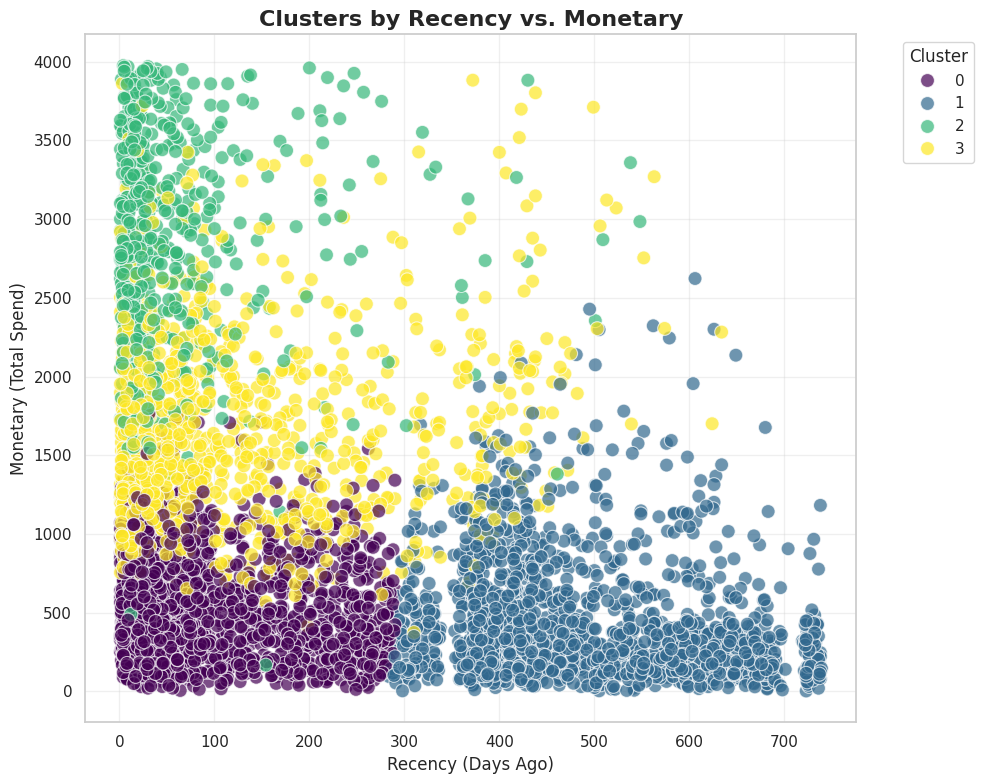

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm_clean, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters by Recency vs. Monetary', fontsize=16, fontweight='bold')
plt.xlabel('Recency (Days Ago)', fontsize=12)
plt.ylabel('Monetary (Total Spend)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()